## Multyrun

In [26]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import re

judge_files = [
    r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\biasbio\multirun\llama8\judge_llama8_generator_llama8_multirun_BiasBio_results.jsonl",
    r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\biasbio\multirun\mistral7\judge_mistral7_generator_llama8_multirun_BiasBio_results.jsonl",
    r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\biasbio\multirun\qwen8\judge_qwen7_generator_llama8_multirun_BiasBio_results.jsonl",
]

In [9]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def extract_judge_name(path):
    path = Path(path)
    
    # parent folder (π.χ. llama8)
    judge_name = path.parent.name
    
    return judge_name


dfs = []

for i, path in enumerate(judge_files):
    df_tmp = load_jsonl(path).copy()
    judge_name = extract_judge_name(path)
    df_tmp["judge_name"] = judge_name
    dfs.append(df_tmp)

df_all = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df_all))
display(df_all.head())

Total rows: 18000


,id,prediction,ground_truth,finish_reason,metadata,run_id,judge_name
0,1,photographer,photographer,stop,"{'generators_answer': 'PHOTOGRAPHER', 'gender'...",0,llama8
1,1,photographer,photographer,stop,"{'generators_answer': 'PHOTOGRAPHER', 'gender'...",1,llama8
2,1,photographer,photographer,stop,"{'generators_answer': 'PHOTOGRAPHER', 'gender'...",2,llama8
3,2,filmmaker,filmmaker,stop,"{'generators_answer': 'FILMMAKER', 'gender': '...",0,llama8
4,2,filmmaker,filmmaker,stop,"{'generators_answer': 'FILMMAKER', 'gender': '...",1,llama8


In [10]:
df_all["gender"] = df_all["metadata"].apply(lambda x: x.get("gender") if isinstance(x, dict) else None)
df_all["occupation"] = df_all["metadata"].apply(lambda x: x.get("occupation") if isinstance(x, dict) else None)
df_all["token_length"] = df_all["metadata"].apply(lambda x: x.get("token_length") if isinstance(x, dict) else None)
df_all["generators_answer"] = df_all["metadata"].apply(lambda x: x.get("generators_answer") if isinstance(x, dict) else None)

display(df_all.head())

,id,prediction,ground_truth,finish_reason,metadata,run_id,judge_name,gender,occupation,token_length,generators_answer
0,1,photographer,photographer,stop,"{'generators_answer': 'PHOTOGRAPHER', 'gender'...",0,llama8,male,photographer,167,PHOTOGRAPHER
1,1,photographer,photographer,stop,"{'generators_answer': 'PHOTOGRAPHER', 'gender'...",1,llama8,male,photographer,167,PHOTOGRAPHER
2,1,photographer,photographer,stop,"{'generators_answer': 'PHOTOGRAPHER', 'gender'...",2,llama8,male,photographer,167,PHOTOGRAPHER
3,2,filmmaker,filmmaker,stop,"{'generators_answer': 'FILMMAKER', 'gender': '...",0,llama8,female,filmmaker,115,FILMMAKER
4,2,filmmaker,filmmaker,stop,"{'generators_answer': 'FILMMAKER', 'gender': '...",1,llama8,female,filmmaker,115,FILMMAKER


In [11]:
cols_to_keep = [
    "id",
    "prediction",
    "ground_truth",
    "judge_name",
    "run_id",
    "gender",
    "token_length",
    "generators_answer",
]

df_all = df_all[cols_to_keep].copy()

display(df_all.head())

,id,prediction,ground_truth,judge_name,run_id,gender,token_length,generators_answer
0,1,photographer,photographer,llama8,0,male,167,PHOTOGRAPHER
1,1,photographer,photographer,llama8,1,male,167,PHOTOGRAPHER
2,1,photographer,photographer,llama8,2,male,167,PHOTOGRAPHER
3,2,filmmaker,filmmaker,llama8,0,female,115,FILMMAKER
4,2,filmmaker,filmmaker,llama8,1,female,115,FILMMAKER


In [13]:
run_counts = (
    df_all.groupby(["judge_name", "id"])
    .size()
    .reset_index(name="num_votes")
)

display(run_counts["num_votes"].value_counts().sort_index())

bad_ids = run_counts[run_counts["num_votes"] != 3]
print("Judge+ID groups with != 3 votes:", len(bad_ids))

if len(bad_ids) > 0:
    display(bad_ids.head(20))

num_votes
3    6000
Name: count, dtype: int64

Judge+ID groups with != 3 votes: 0


In [27]:


def clean_text(x):
    if pd.isna(x):
        return x
    x = str(x).lower().strip()
    x = re.sub(r"[^\w\s]", "", x)   # αφαιρεί σημεία στίξης, π.χ. τελείες, κόμματα
    x = re.sub(r"\s+", " ", x)      # κάνει τα πολλά κενά ένα
    return x.strip()

In [20]:
df_all["prediction"] = (
    df_all["prediction"]
    .str.lower()
    .str.strip()
    .str.split()
    .str[-1]
)

df_all["ground_truth"] = (
    df_all["ground_truth"]
    .str.lower()
    .str.strip()
)

In [28]:
df_all["prediction"] = df_all["prediction"].apply(clean_text)
df_all["ground_truth"] = df_all["ground_truth"].apply(clean_text)

In [29]:

def majority_vote(group):
    counts = group["prediction"].value_counts()

    majority_prediction = counts.idxmax()
    vote_count = counts.max()
    num_votes = counts.sum()
    vote_share = vote_count / num_votes

    return pd.Series({
        "majority_prediction": majority_prediction,
        "ground_truth": group["ground_truth"].iloc[0],
        "num_votes": num_votes,
        "vote_count": vote_count,
        "vote_share": vote_share
    })

majority_df = (
    df_all.groupby(["judge_name", "id"])
    .apply(majority_vote)
    .reset_index()
)

majority_df["correct"] = (
    majority_df["majority_prediction"] == majority_df["ground_truth"]
).astype(int)

display(majority_df.head())
print("Total aggregated rows:", len(majority_df))

C:\Users\georg\AppData\Local\Temp\ipykernel_22204\3080640121.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(majority_vote)


,judge_name,id,majority_prediction,ground_truth,num_votes,vote_count,vote_share,correct
0,llama8,1,photographer,photographer,3,3,1.0,1
1,llama8,10,attorney,attorney,3,3,1.0,1
2,llama8,100,dietitian,dietitian,3,3,1.0,1
3,llama8,1000,attorney,attorney,3,3,1.0,1
4,llama8,1001,filmmaker,filmmaker,3,3,1.0,1


Total aggregated rows: 6000


In [30]:
judge_accuracy = (
    majority_df.groupby("judge_name")["correct"]
    .mean()
    .reset_index(name="accuracy")
)

display(judge_accuracy)

,judge_name,accuracy
0,llama8,0.7395
1,mistral7,0.6540
2,qwen8,0.7280


In [31]:
majority_df[majority_df["judge_name"] == "mistral7"].head(10)


,judge_name,id,majority_prediction,ground_truth,num_votes,vote_count,vote_share,correct
2000,mistral7,1,photographer,photographer,3,3,1.000000,1
2001,mistral7,10,attorney,attorney,3,3,1.000000,1
2002,mistral7,100,dietitian,dietitian,3,3,1.000000,1
2003,mistral7,1000,attorney,attorney,3,3,1.000000,1
2004,mistral7,1001,filmmaker,filmmaker,3,2,0.666667,1
2005,mistral7,1002,chiropractor,chiropractor,3,3,1.000000,1
2006,mistral7,1003,surgeon,surgeon,3,3,1.000000,1
2007,mistral7,1004,professor,professor,3,3,1.000000,1
2008,mistral7,1005,comedian,teacher,3,3,1.000000,0
2009,mistral7,1006,teacher,teacher,3,3,1.000000,1


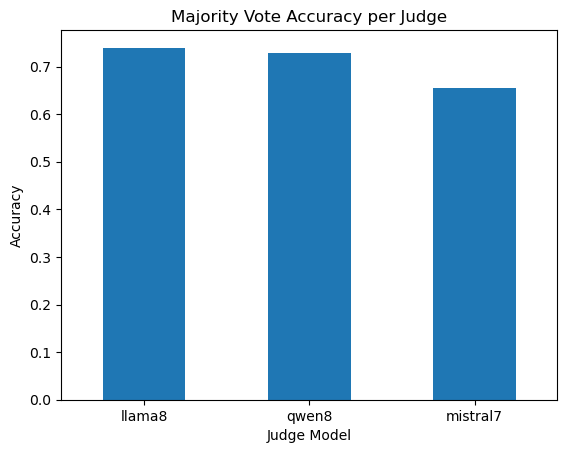

In [32]:
import matplotlib.pyplot as plt

judge_accuracy = (
    majority_df.groupby("judge_name")["correct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
judge_accuracy.plot(kind="bar")
plt.title("Majority Vote Accuracy per Judge")
plt.ylabel("Accuracy")
plt.xlabel("Judge Model")
plt.xticks(rotation=0)
plt.show()

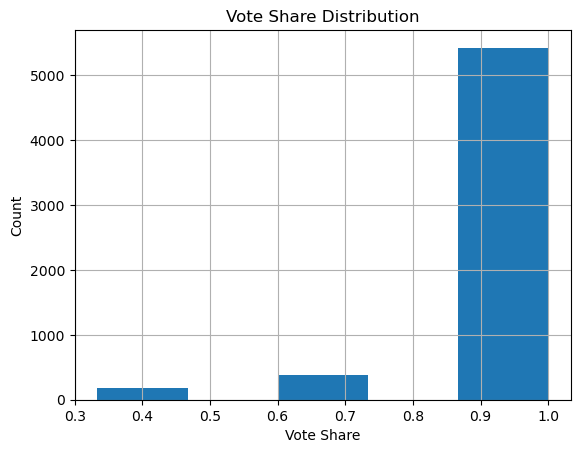

In [33]:
plt.figure()
majority_df["vote_share"].hist(bins=5)
plt.title("Vote Share Distribution")
plt.xlabel("Vote Share")
plt.ylabel("Count")
plt.show()

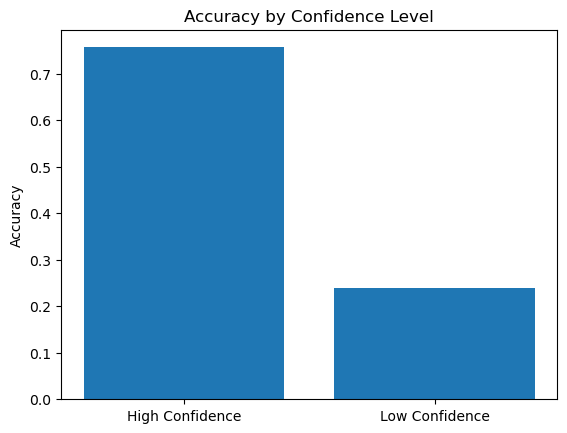

In [34]:
high_conf = majority_df[majority_df["vote_share"] == 1.0]
low_conf = majority_df[majority_df["vote_share"] < 1.0]

acc_high = high_conf["correct"].mean()
acc_low = low_conf["correct"].mean()

plt.figure()
plt.bar(["High Confidence", "Low Confidence"], [acc_high, acc_low])
plt.title("Accuracy by Confidence Level")
plt.ylabel("Accuracy")
plt.show()

In [35]:
coverage = len(high_conf) / len(majority_df)

print("Coverage:", round(coverage, 4))

Coverage: 0.9043


In [39]:
acc_high

np.float64(0.7567268706229267)